In [26]:
## TEST DELETE AFTER
import pandas as pd
import numpy as np
from pandas import DataFrame

def reorder_labels_df(path: str) -> DataFrame:
    labels_df = pd.read_csv(path)
    CHEXBERT_LABELS = [
        "Enlarged Cardiomediastinum", "Cardiomegaly", "Lung Opacity",
        "Lung Lesion", "Edema", "Consolidation", "Pneumonia", "Atelectasis",
        "Pneumothorax", "Pleural Effusion", "Pleural Other", "Fracture",
        "Support Devices", "No Finding",
    ]
    mapping = {
        np.nan: 0,   # NaN -> 0
        1.0: 1,      # 1.0 -> 1
        0.0: 2,      # 0.0 -> 2
        -1.0: 3      # -1.0 -> 3

    }
    for col in CHEXBERT_LABELS:
        labels_df[col] = labels_df[col].map(mapping)
    # Since map does not directly handle NaN keys well, fix NaNs separately
    for col in CHEXBERT_LABELS:
        labels_df[col] = labels_df[col].fillna(0).astype(int)

    return labels_df


labels_df = reorder_labels_df("/home/public/mkamal/dataset/filtered_data/reports_label.csv")


from sklearn.model_selection import train_test_split
def load_and_split(csv_path: str, val_size: float = 0.1, test_size: float = 0.00001, seed: int = 42, logger = None):
    """
    Splits by unique patient ID to prevent data leakage.
    Same patient will never appear in more than one split.
    """
    df = pd.read_csv(csv_path)
    patients = df['deid_patient_id'].unique().tolist()
    

    # First split off test set
    train_val_patients, test_patients = train_test_split(
        patients,
        test_size=test_size,
        random_state=seed
    )

    # Then split remaining into train/val
    relative_val_size = val_size / (1.0 - test_size)  # adjust val proportion
    train_patients, val_patients = train_test_split(
        train_val_patients,
        test_size=relative_val_size,
        random_state=seed
    )

    train_df = df[df['deid_patient_id'].isin(train_patients)]
    val_df   = df[df['deid_patient_id'].isin(val_patients)]
    test_df  = df[df['deid_patient_id'].isin(test_patients)]

    return train_df, val_df, test_df

train_df, valdf, tdf = load_and_split("/home/public/mkamal/dataset/filtered_data/train/train_cleaned.csv")
valdf = pd.read_csv("/home/public/mkamal/dataset/filtered_data/valid/valid_cleaned.csv")

intersection_df = labels_df.merge(
    valdf[['path_no_ext']],
    on='path_no_ext',
    how='inner'
)

labels_df = intersection_df

print(len(labels_df))



52


                            positive  uncertain  negative  missing  \
Support Devices                   40          1        11        0   
Lung Opacity                      27          2        23        0   
Pleural Effusion                  27         10        14        1   
Edema                             19          6        26        1   
Cardiomegaly                      10          0        40        2   
Atelectasis                       10          0        34        8   
Pneumothorax                       4         12        36        0   
Fracture                           2          0        50        0   
Lung Lesion                        2          0        50        0   
Consolidation                      2          6        38        6   
No Finding                         2          0        50        0   
Pleural Other                      2          0        49        1   
Enlarged Cardiomediastinum         1          1        47        3   
Pneumonia           

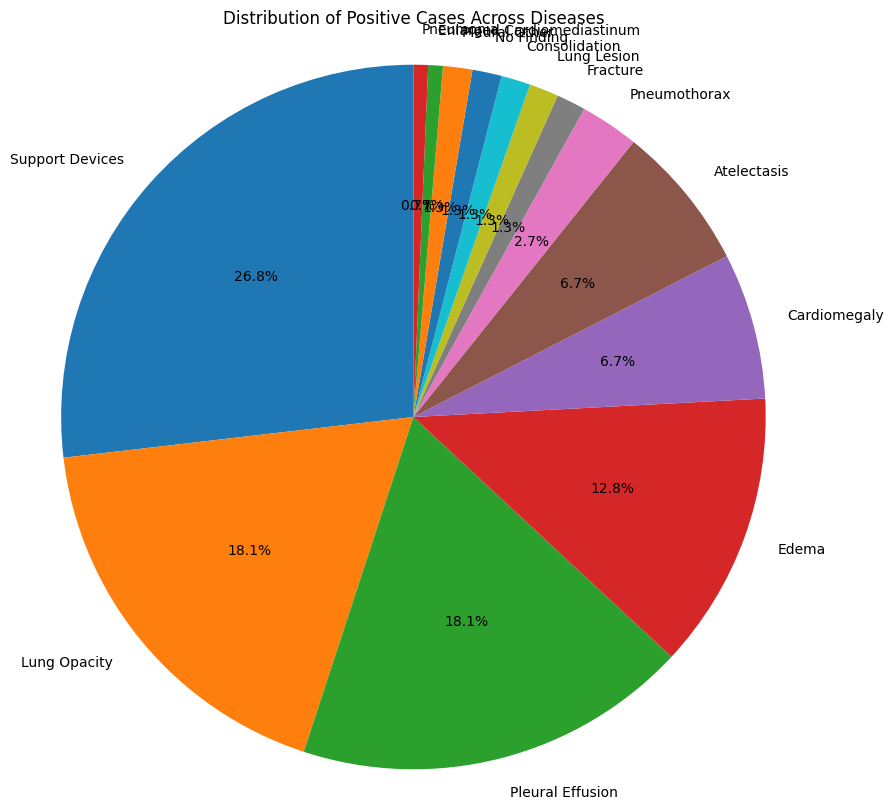

In [27]:
disease_cols = [
    "Enlarged Cardiomediastinum",
    "Cardiomegaly",
    "Lung Opacity",
    "Lung Lesion",
    "Edema",
    "Consolidation",
    "Pneumonia",
    "Atelectasis",
    "Pneumothorax",
    "Pleural Effusion",
    "Pleural Other",
    "Fracture",
    "Support Devices",
    "No Finding"
]

# Count how many studies have each disease label present
# Assuming:
# 0 = negative
# 1 = positive
# 2 = uncertain
# 3 = blank / missing


positive_counts = (labels_df[disease_cols] == 1).sum()
uncertain_counts = (labels_df[disease_cols] == 2).sum()
missing_counts = (labels_df[disease_cols] == 3).sum()
negative_counts = (labels_df[disease_cols] == 0).sum()

distribution_df = pd.DataFrame({
    "positive": positive_counts,
    "uncertain": uncertain_counts,
    "negative": negative_counts,
    "missing": missing_counts
})

distribution_df["positive_pct"] = (
    distribution_df["positive"] / len(labels_df) * 100
).round(2)

distribution_df = distribution_df.sort_values(
    by="positive",
    ascending=False
)

print(distribution_df)
import matplotlib.pyplot as plt

# Sum each label column across all findings
totals = distribution_df[["positive", "uncertain", "negative", "missing"]].sum()

import matplotlib.pyplot as plt

# Pie chart for positive percentages by disease
plt.figure(figsize=(10, 10))

plt.pie(
    distribution_df["positive_pct"],
    labels=distribution_df.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribution of Positive Cases Across Diseases")
plt.axis('equal')  # Keep pie chart circular
plt.show()

Columns: ['path_to_image', 'deid_patient_id', 'patient_report_date_order', 'frontal_lateral', 'clinical_history', 'condensed_report', 'path_no_ext', 'split', 'path_to_png']
Shape: (95657, 9)

── Character Lengths ──
  Mean:    402
  Median:  338
  95th %:  873
  99th %:  1332
  Max:     3194

── Word Lengths ──
  Mean:    59
  Median:  49
  95th %:  128
  99th %:  197
  Max:     474

── Recommendation ──
  Conservative (95th %): 128  words
  Safe        (99th %): 256  words


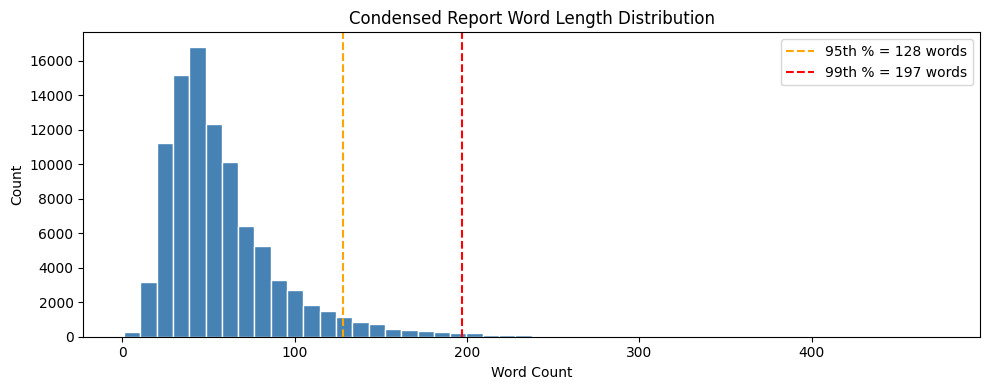

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = "/home/public/mkamal/dataset/filtered_data/train/train.csv"
df = pd.read_csv(csv_path)

print("Columns:", df.columns.tolist())
print("Shape:", df.shape)

report_col = "condensed_report"

# ── 1. Character lengths ─────────────────────────────────────────────────────
char_lengths = df[report_col].dropna().apply(len)
print("\n── Character Lengths ──")
print(f"  Mean:    {char_lengths.mean():.0f}")
print(f"  Median:  {char_lengths.median():.0f}")
print(f"  95th %:  {char_lengths.quantile(0.95):.0f}")
print(f"  99th %:  {char_lengths.quantile(0.99):.0f}")
print(f"  Max:     {char_lengths.max():.0f}")

# ── 2. Word lengths (simple whitespace split) ────────────────────────────────
word_lengths = df[report_col].dropna().apply(lambda x: len(x.split()))
print("\n── Word Lengths ──")
print(f"  Mean:    {word_lengths.mean():.0f}")
print(f"  Median:  {word_lengths.median():.0f}")
print(f"  95th %:  {word_lengths.quantile(0.95):.0f}")
print(f"  99th %:  {word_lengths.quantile(0.99):.0f}")
print(f"  Max:     {word_lengths.max():.0f}")

# ── 3. Recommended max_len ───────────────────────────────────────────────────
p95 = int(word_lengths.quantile(0.95))
p99 = int(word_lengths.quantile(0.99))

def next_power_of_2(x):
    return 1 if x == 0 else 2**int(np.ceil(np.log2(x)))

print("\n── Recommendation ──")
print(f"  Conservative (95th %): {next_power_of_2(p95)}  words")
print(f"  Safe        (99th %): {next_power_of_2(p99)}  words")

# ── 4. Plot ──────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.hist(word_lengths, bins=50, color="steelblue", edgecolor="white")
plt.axvline(p95, color="orange", linestyle="--", label=f"95th % = {p95} words")
plt.axvline(p99, color="red",    linestyle="--", label=f"99th % = {p99} words")
plt.xlabel("Word Count")
plt.ylabel("Count")
plt.title("Condensed Report Word Length Distribution")
plt.legend()
plt.tight_layout()
plt.savefig("report_length_dist.png", dpi=150)
plt.show()

In [1]:
import pandas as pd
import re

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

dt = pd.read_csv("/home/public/mkamal/dataset/filtered_data/train/train.csv")

# ─────────────────────────────────────────────────────────────────────────────
# Fix patterns
#
# RULE: [^\n]* only on whole-line metadata (SUMMARY, SIGNATURE, ACCESSION)
#       Inline patterns strip the token only — clinical content is kept
# ─────────────────────────────────────────────────────────────────────────────

_RE_SUMMARY = re.compile(
    r'(?:'
    r'end\s+of\s+impression'
    r'|\d+[-\s]+(?:abnormal|normal|significant|action|finding|reviewed)'
    r'|(?:may need action|previously reported|possibly significant'
    r'|action required|no action required)'
    r')'
    r'[^\n]*',
    re.IGNORECASE
)
_RE_SUMMARY_FRAGMENT = re.compile(r'[,\.\s]+may\s+need\s+action\b', re.IGNORECASE)
# Strips accession token only — NOT rest of line
# Covers: "accession #7154407945477 -", "accession ##17439927950",
#         "accession #554-129-755-142", "accession #kdeixbcw:",
#         "accession # 0574423:", "accession number:"
# The ID token is alphanumeric + hyphens/dots (synthetic de-identified IDs)
_RE_ACCESSION   = re.compile(
    r'\baccession\s*(?:number)?\s*#*\s*[\w\-\.]*\s*[-:\,]?\s*',
    re.IGNORECASE
)
_RE_SIGNATURE   = re.compile(r'i\s+have\s+personally\s+reviewed.*?(?:\n|$)', re.IGNORECASE)
_RE_TRANSCRIBED = re.compile(r'with\s+the\s+report\s+transcribed\s+above.*?(?:\n|$)', re.IGNORECASE)
_RE_BY_NAME     = re.compile(r'\bby\s*:\s*[A-Za-z]+,\s*[A-Za-z][\w\s\.]*?(?=\s+on\s*:|\s*$|\n)', re.IGNORECASE)
_RE_DISCUSSED   = re.compile(r'\bwere\s+discussed\s+with\s+\w+(?:\s+\w+)?\s+(?:md|dr|np|pa)\b[^\n]*', re.IGNORECASE)

# Institution — consumes trailing time token in same pass
# prevents "kratikal 19:25 hours:" leaving orphaned "hours:"
_RE_INSTITUTION = re.compile(
    r'\b(?:usc\s+center\s+for\s+body\s+computing|kollabio|kratikal)'
    r'(?:\s+\d{1,2}:\d{2}\s*(?:hours?|hrs?)?|\s+\d{3,4}\s*(?:hours?|hrs?)?)?'
    r'\s*:?',
    re.IGNORECASE
)

# Time token only — military and HH:MM with all am/pm variants
_RE_TIME = re.compile(
    r'\b(?:at\s+)?'
    r'(?:'
    r'\d{3,4}\s+(?:hours?|hrs?)'
    r'|'
    r'\d{1,2}:\d{2}'
    r'(?:\s*[ap]\.\s*m\.|\s*[ap]\.m\.|\s*[ap]\s*m)?'
    r'\s*:?'
    r')',
    re.IGNORECASE
)

# Orphaned "a. m." / "p. m." left after partial time stripping
# e.g. "on 8:27 a. m." → _RE_ON_DATETIME strips "on 8:27" → "a. m." remains
# Run twice: once early, once after all time patterns
_RE_AM_PM_ORPHAN = re.compile(r'\b[ap]\.\s*m\.', re.IGNORECASE)

# Orphaned "and/or HH:MM" after first time in sequence stripped
# "on 8:27 a. m. and 10:48 a. m." → "and 10:48" orphan
_RE_CONJ_TIME = re.compile(r'\b(?:and|or)\s+\d{1,2}:\d{2}\s*', re.IGNORECASE)

# "on DATE/TIME" — token only, run before generic date/time stripping
_RE_ON_DATETIME = re.compile(
    r'\bon\s+'
    r'(?:'
    r'\d{1,2}[\/\-]\d{1,2}[\/\-]\d{2,4}'
    r'|(?:january|february|march|april|may|june|july|august'
    r'|september|october|november|december)'
    r'\s+\d{1,2}(?:st|nd|rd|th)?(?:\s*,?\s*\d{2,4})?'
    r'|\d{1,2}:\d{2}(?:\s*[ap]\.\s*m\.|\s*[ap]\.m\.|\s*[ap]\s*m)?'
    r')\b\s*:?',
    re.IGNORECASE
)

# "DATE at TIME" combined token
_RE_DATE_AT_TIME = re.compile(
    r'\b\d{1,2}[\/\-]\d{1,2}[\/\-]\d{2,4}'
    r'\s+at\s+'
    r'(?:\d{3,4}\s+(?:hours?|hrs?)|\d{1,2}:\d{2}(?:\s*[ap]\.?\s*m\.?)?)',
    re.IGNORECASE
)

# "since/from/dated/as of DATE"
_RE_DATE_INLINE = re.compile(
    r'\b(?:since|from|dated?|as\s+of|compared\s+to\s+(?:the\s+)?prior)'
    r'\s+'
    r'(?:'
    r'\d{1,2}[\/\-]\d{1,2}[\/\-]\d{2,4}'
    r'|(?:january|february|march|april|may|june|july|august'
    r'|september|october|november|december)'
    r'\s+\d{1,2}(?:st|nd|rd|th)?(?:\s*,?\s*\d{2,4})?'
    r')',
    re.IGNORECASE
)

_RE_COMPARISON_DATE  = re.compile(r'\bcomparison\s+to\s+\d{1,2}[\/\-]\d{1,2}[\/\-]\d{2,4}\b\s*[,\.]?', re.IGNORECASE)
_RE_COMPARISON_EMPTY = re.compile(r'\bcomparison\s+to\s*[,\.]?\s*(?=[,\.\s]|$)', re.IGNORECASE)

# Numeric dates with optional trailing colon: 11/03/21, 10/9/11:, 4/5/1993 :
_RE_DATE_NUMERIC = re.compile(r'\b\d{1,2}[\/\-]\d{1,2}[\/\-]\d{2,4}\b\s*:?')

# Written dates with optional trailing colon: "MARCH 11", "october 9, 2011:"
_RE_DATE_WRITTEN = re.compile(
    r'\b(?:january|february|march|april|may|june|july|august'
    r'|september|october|november|december)'
    r'\s+\d{1,2}(?:st|nd|rd|th)?(?:\s*,?\s*\d{2,4})?\b\s*:?',
    re.IGNORECASE
)

# Standalone 4-digit years — protected against clinical units
_RE_DATE_YEAR = re.compile(
    r'(?<![x\d])(?<!\d\.)\b(?:19|20)\d{2}\b'
    r'(?!\s*(?:cm|mm|ml|mg|kg|lbs?|units?|cc))'
)

_RE_NUM_START   = re.compile(r'^\s*(?<!\d)\d+\.\s*(?=[A-Za-z])')
_RE_NUM_NEWLINE = re.compile(r'\n\s*(?<!\d)\d+\.\s*(?=[A-Za-z])')
_RE_NUM_INLINE  = re.compile(r'(?<=[\s])(?<!\d)\d+\.\s*(?=[A-Za-z])')
_RE_PAREN_NUM   = re.compile(r'\(\d+\)\s*')
_RE_WHITESPACE  = re.compile(r'[\n\r\t]+')
_RE_MERGE_SENT  = re.compile(r'\.(?=[A-Z])')
_RE_MULTI_SPACE = re.compile(r' {2,}')
_RE_DANGLING    = re.compile(r'\s*[,\.]\s*\.')
_RE_LEAD_PUNCT  = re.compile(r'^\s*[,:\.]\s*')
_RE_TRAIL_COMMA = re.compile(r',\s*$')


def fix_noise(text: str) -> str:
    if not isinstance(text, str) or pd.isna(text):
        return text

    # 2. Institution names (consumes trailing time in same pass)
    text = _RE_INSTITUTION.sub('', text)

    # 3. Date+time combinations — most specific first
    text = _RE_ON_DATETIME.sub('', text)      # "on DATE/TIME"
    text = _RE_CONJ_TIME.sub('', text)        # "and/or HH:MM" orphan
    text = _RE_AM_PM_ORPHAN.sub('', text)     # "a. m." orphan pass 1
    text = _RE_DATE_AT_TIME.sub('', text)     # "DATE at TIME"
    text = _RE_COMPARISON_DATE.sub('', text)  # "comparison to DATE"
    text = _RE_DATE_INLINE.sub('', text)      # "since/from/dated DATE"

    # 4. Standalone date tokens
    text = _RE_DATE_NUMERIC.sub('', text)
    text = _RE_DATE_WRITTEN.sub('', text)
    text = _RE_DATE_YEAR.sub('', text)

    # 5. Standalone time tokens
    text = _RE_TIME.sub('', text)
    text = _RE_AM_PM_ORPHAN.sub('', text)     # "a. m." orphan pass 2

    # 6. Comparison empty remnants
    text = _RE_COMPARISON_EMPTY.sub('', text)

    # 7. Numbered markers — before whitespace collapse
    text = _RE_NUM_START.sub('', text)
    text = _RE_NUM_NEWLINE.sub(' ', text)
    text = _RE_PAREN_NUM.sub('', text)

    # 8. Whitespace normalisation
    text = _RE_WHITESPACE.sub(' ', text)
    text = _RE_NUM_INLINE.sub('', text)
    text = _RE_MERGE_SENT.sub('. ', text)
    text = _RE_MULTI_SPACE.sub(' ', text)

    # 9. Dangling punctuation
    text = _RE_DANGLING.sub('.', text)
    text = _RE_LEAD_PUNCT.sub('', text)
    text = _RE_TRAIL_COMMA.sub('', text)
    text = _RE_MULTI_SPACE.sub(' ', text)

    return text.strip()


NOISE_PATTERNS = {
    "end of impression":           r'\bend of impression\b',
    "may need action":             r'\bmay need action\b',
    "i have personally reviewed":  r'\bi have personally reviewed\b',
    "with the report transcribed": r'\bwith the report transcribed\b',
    "previously reported":         r'\bpreviously reported\b',
    "accession number":            r'\baccession\s*number\b',
    "this report has been":        r'\bthis report has been\b',
    "summary header":              r'(?:^|\s)summary\s*:',
    "numbered marker":             r'(?<!\d)\b\d+\.\s*[a-zA-Z]',
    "numeric date":                r'\b\d{1,2}[\/\-]\d{1,2}[\/\-]\d{2,4}\b',
    "written date":                r'\b(?:january|february|march|april|may|june|july|august|september|october|november|december)\s+\d{1,2}',
    "standalone year":             r'(?<!\d)\b(?:19|20)\d{2}\b(?!\s*(?:cm|mm|ml|mg|kg))',
    "by: name on: date":           r'\bby\s*:\s*\w+,\s*\w+',
    "usc/kollabio/kratikal":       r'\b(?:usc\s+center\s+for\s+body\s+computing|kollabio|kratikal)\b',
    "timestamp (military)":        r'\b\d{3,4}\s+(?:hours?|hrs?)\b',
    "12-hour time":                r'\b\d{1,2}:\d{2}\s*[ap]\.?\s*m\.?',
    "24-hour time (HH:MM)":        r'\b\d{1,2}:\d{2}\b',
    "am/pm orphan":                r'\b[ap]\.\s*m\.',
    "were discussed with":         r'\bwere\s+discussed\s+with\b',
}


def audit_column(series: pd.Series, col_name: str, n_samples: int = 3):
    non_null = series.dropna()
    total    = len(non_null)

    print(f"\n{'='*70}")
    print(f"  Column : {col_name}  ({total:,} non-null rows)")
    print(f"{'='*70}")
    print(f"  {'Pattern':<45} {'Count':>7}  {'%':>6}")
    print(f"  {'-'*65}")

    hits = {}
    for label, pattern in NOISE_PATTERNS.items():
        mask     = non_null.str.contains(pattern, case=False, regex=True)
        count    = int(mask.sum())
        matching = non_null[mask]
        hits[label] = (count, matching)
        pct  = 100 * count / total if total > 0 else 0
        flag = "⚠️ " if count > 0 else "✓ "
        print(f"  {flag} {label:<43} {count:>7,}  {pct:>5.2f}%")

    any_hit = any(c > 0 for c, _ in hits.values())
    if any_hit:
        print(f"\n  {'─'*65}")
        print(f"  SAMPLE ROWS (up to {n_samples} per pattern)")
        print(f"  {'─'*65}")
        for label, (count, matching) in hits.items():
            if count == 0:
                continue
            print(f"\n  [{label}]  — {count:,} rows")
            for i, (idx, val) in enumerate(matching.head(n_samples).items()):
                highlighted = re.sub(
                    NOISE_PATTERNS[label],
                    lambda m: f">>>{m.group()}<<<",
                    str(val), flags=re.IGNORECASE
                )
                print(f"    ({i+1}) {highlighted[:220]}")
    else:
        print(f"\n  ✓  Column is clean.")

    all_affected = set()
    for _, matching in hits.values():
        all_affected.update(matching.index.tolist())
    print(f"\n  Unique affected rows : {len(all_affected):,} / {total:,} "
          f"({100*len(all_affected)/max(total,1):.2f}%)")
    return hits


# ─────────────────────────────────────────────────────────────────────────────
# Main — unit tests → audit → fix → re-audit → 50-row diff (no save)
# ─────────────────────────────────────────────────────────────────────────────

COLS = ["section_impression_gen", "section_findings_gen"]

# Pass 1 — before
print("\n" + "="*70)
print("  PASS 1 — BEFORE FIXING")
print("="*70)
for col in COLS:
    if col in dt.columns:
        audit_column(dt[col], col)
    else:
        print(f"\n[WARN] '{col}' not found. Available: {dt.columns.tolist()}")

# Apply fixes to copy — original untouched
print("\n" + "="*70)
print("  APPLYING FIXES (in memory — not saved)")
print("="*70)
dt_fixed = dt.copy()
for col in COLS:
    if col not in dt_fixed.columns:
        continue
    before_null = dt_fixed[col].isna().sum()
    dt_fixed[col] = dt_fixed[col].apply(fix_noise)
    dt_fixed[col] = dt_fixed[col].replace('', pd.NA)
    newly_empty = dt_fixed[col].isna().sum() - before_null
    print(f"  {col}: done. Rows newly empty: {newly_empty:,}")

# Pass 2 — after
print("\n" + "█"*70)
print("  PASS 2 — AFTER FIXING")
print("█"*70)
for col in COLS:
    if col in dt_fixed.columns:
        audit_column(dt_fixed[col], col)




  PASS 1 — BEFORE FIXING

  Column : section_impression_gen  (83,230 non-null rows)
  Pattern                                         Count       %
  -----------------------------------------------------------------
  ⚠️  end of impression                                 7   0.01%
  ⚠️  may need action                                   3   0.00%
  ✓  i have personally reviewed                        0   0.00%
  ✓  with the report transcribed                       0   0.00%
  ⚠️  previously reported                              20   0.02%
  ⚠️  accession number                                 10   0.01%
  ✓  this report has been                              0   0.00%
  ✓  summary header                                    0   0.00%
  ⚠️  numbered marker                                 744   0.89%
  ⚠️  numeric date                                  6,002   7.21%
  ⚠️  written date                                    751   0.90%
  ⚠️  standalone year                               5,492   6

# MAY NEED ACTION

In [ ]:
import re
import pandas as pd

_RE_MAY_NEED_ACTION = re.compile(
    r'^[,\s]*may\s+need\s+action.*$|[,\s]+may\s+need\s+action.*$',
    re.IGNORECASE | re.DOTALL
)

def remove_may_need_action(text: str) -> str:
    if not isinstance(text, str) or pd.isna(text):
        return None
    result = _RE_MAY_NEED_ACTION.sub('', text).strip()
    return result if result else None

for col in ["section_impression_gen", "section_findings_gen"]:
    if col in dt_fixed.columns:
        dt_fixed[col] = dt_fixed[col].apply(remove_may_need_action)

In [14]:
# Rows where clinical history is null/empty
missing_clinical = dt_fixed[dt_fixed["clinical_history"].isna() | 
                      (dt_fixed["clinical_history"].str.strip() == "")]

# Among those, check if the report contains \nHISTORY: or \nCLINICAL HISTORY:
pattern = re.compile(

    r'\n(?:CLINICAL\s+(?:DATA\s+)?)?HISTORY\s*:',

    re.IGNORECASE

)

missing_clinical.head(30)
# leaking = missing_clinical[
#     missing_clinical["report"].str.contains(pattern, na=False)
# ]

# print(f"Total samples with null clinical history : {len(missing_clinical)}")
# print(f"Of those, reports containing HISTORY tag : {len(leaking)}")
# print(f"Leak rate                                : {len(leaking)/len(missing_clinical)*100:.1f}%")

# # Inspect the leaking ones
# print("\nSample leaking reports:")
# print(leaking["report"].head(5).values)


,report,path_to_image,path_to_png,path_no_ext,deid_patient_id,patient_report_date_order,split,frontal_lateral,ap_pa,clinical_history,section_impression_gen,section_impression,section_findings_gen,section_findings,condensed_report
13,"NARRATIVE:\nSINGLE VIEW CHEST: 7/5/2013 at 2055 hours\n \nCOMPARISON: 7/5/2013\n \nIMPRESSION:\n \n1. INCREASED LEFT RETROCARDIAC OPACITY, WHICH MAY REPRESENT \nATELECTASIS VERSUS PNEUMONIA. LUNGS OTHERWISE REMAIN CLEAR. STABLE \nCARDIOMEDIASTINAL SILHOUETTE ALLOWING FOR SUPINE POSITIONING. \nSUMMARY:4-POSSIBLE SIGNIFICANT FINDINGS, MAY NEED ACTION.\n \nACCESSION NUMBER:\na0FTBVF3tZ\nThis report has been anonymized. All dates are offset from the actual dates by a fixed interval associated with the patient.",train/patient53157/study1/view1_frontal.jpg,train/patient53157/study1/view1_frontal.png,train/patient53157/study1/view1_frontal,patient53157,1,train,Frontal,AP,NaN,"increased left retrocardiac opacity, which may represent atelectasis versus pneumonia. lungs otherwise remain clear. stable cardiomediastinal silhouette allowing for supine positioning.","\n \n1. INCREASED LEFT RETROCARDIAC OPACITY, WHICH MAY REPRESENT \nATELECTASIS VERSUS PNEUMONIA. LUNGS OTHERWISE REMAIN CLEAR. STABLE \nCARDIOMEDIASTINAL SILHOUETTE ALLOWING FOR SUPINE POSITIONING. \n",NaN,", MAY NEED ACTION.",", may need action. increased left retrocardiac opacity, which may represent atelectasis versus pneumonia. lungs otherwise remain clear. stable cardiomediastinal silhouette allowing for supine positioning."
16,"NARRATIVE:\nCHEST: 6-10-2005\nCOMPARISON: None available.\nIMPRESSION:\n1. THERE IS A RIGHT PLEURAL EFFUSION. THERE IS A LEFT ANTERIOR\nCHEST WALL AICD. THERE IS NO PNEUMOTHORAX.\nEND OF IMPRESSION:\nSUMMARY:4-POSSIBLE SIGNIFICANT FINDINGS, MAY NEED ACTION\nI have personally reviewed the images for this examination and agree\nwith the report transcribed above.\nBy: ROSARIO, TANNER C. on: 6/10/2005\n \nACCESSION NUMBER:\n#vnfnhoafmxi\nThis report has been anonymized. All dates are offset from the actual dates by a fixed interval associated with the patient.",train/patient11162/study1/view1_frontal.jpg,train/patient11162/study1/view1_frontal.png,train/patient11162/study1/view1_frontal,patient11162,1,train,Frontal,AP,NaN,there is a right pleural effusion. there is a left anterior chest wall aicd. there is no pneumothorax.,\n1. THERE IS A RIGHT PLEURAL EFFUSION. THERE IS A LEFT ANTERIOR\nCHEST WALL AICD. THERE IS NO PNEUMOTHORAX.\n,NaN,", MAY NEED ACTION\nI have personally reviewed the images for this examination and agree\nwith the report transcribed above.\nBy: ROSARIO, TANNER C. on: 6/10/2005",", may need action by: rosario, tanner c. on: 6/10/2005 there is a right pleural effusion. there is a left anterior chest wall aicd. there is no pneumothorax."
18,"NARRATIVE:\nTWO VIEW CHEST: 2/21/2002.\nCLINICAL DATA: Heart transplant.\nCOMPARISON: 2/21/2002.\nIMPRESSION:\n1. STABLE POST-SURGICAL THORAX WITH MEDIAN STERNOTOMY WIRES AND\nSURGICAL CLIPS OVERLYING THE LEFT HILUM. DENSE CALCIFICATIONS ARE\nSEEN PROJECTING OVER THE RIGHT HILUM. THESE MAY BE RELATED TO\nUNDERLYING CALCIFIED LYMPH NODES.\n2. STABLE SMALL RIGHT PLEURAL EFFUSION. THE LUNGS ARE OTHERWISE\nGROSSLY CLEAR.\n3. STABLE CARDIOMEDIASTINAL SILHOUETTE.\nEND OF IMPRESSION:\nSUMMARY:2-ABNORMAL, PREVIOUSLY REPORTED\n \nACCESSION NUMBER:\n2372063\nThis report has been anonymized. All dates are offset from the actual dates by a fixed interval associated with the patient.",train/patient11162/study6/view1_frontal.jpg,train/patient11162/study6/view1_frontal.png,train/patient11162/study6/view1_frontal,patient11162,8,train,Frontal,PA,NaN,stable post-surgical thorax with median sternotomy wires and surgical clips overlying the left hilum. dense calcifications are seen projecting over the right hilum. these may be related to underlying calcified lymph nodes. stable small right pleural effusion. the lungs are otherwise grossly clear. stable cardiomediastinal silhouette.,\n1. ST

In [7]:
 #Random 50-row sample of changed rows per column
print("\n" + "█"*70)
print("  RANDOM SAMPLE — 50 changed rows per column")
print("█"*70)
for col in COLS:
    if col not in dt.columns:
        continue

    changed_mask = dt[col].fillna('') != dt_fixed[col].fillna('')
    changed_idx  = dt.index[changed_mask].tolist()
    n_changed    = len(changed_idx)

    print(f"\n  Column: {col}  ({n_changed:,} rows changed)")

    # Sample up to 50
    sample_idx = (
        pd.Series(changed_idx)
        .sample(min(50, n_changed), random_state=42)
        .tolist()
    )

    for i, idx in enumerate(sample_idx):
        before = str(dt.loc[idx, col])
        after  = str(dt_fixed.loc[idx, col])
        print(f"\n  [{i+1:02d}] idx={idx}")
        print(f"  BEFORE: {before[:]}")
        print(f"  AFTER : {after[:]}")

print(f"\n{'='*70}")
print("  NOT SAVED — inspect diff above then save with:")
print("  dt_fixed.to_csv('/home/public/mkamal/dataset/filtered_data/train/train_cleaned.csv', index=False)")
print(f"{'='*70}")


██████████████████████████████████████████████████████████████████████
  RANDOM SAMPLE — 50 changed rows per column
██████████████████████████████████████████████████████████████████████

  Column: section_impression_gen  (8,772 rows changed)

  [01] idx=80893
  BEFORE: ap view of the semi-erect chest on 5-22-2011 at 0754 hours shows post sternotomy surgical changes with wire loops, coronary ostium markers, and numerous vascular clips in the mediastinum, consistent with prior coronary artery bypass operation. there is a loculated right pneumothorax at the right base, along with another small loculated pneumothorax at the right apex. the right chest tube is not changed in position. there is diffuse right parenchymal opacities, consistent with atelectasis versus consolidation versus aspiration. there is diffuse osteopenia.
  AFTER : ap view of the semi-erect chest shows post sternotomy surgical changes with wire loops, coronary ostium markers, and numerous vascular clips in the mediasti

In [8]:
import pandas as pd
import re


def truncation_check(
    dt_before: pd.DataFrame,
    dt_after:  pd.DataFrame,
    cols:      list,
    ratio_threshold: float = 0.4,
    min_before_words: int  = 10,
    n_samples: int         = 20,
):
    """
    Flag rows where cleaning removed too many words.

    Parameters
    ----------
    dt_before         : original dataframe (before fix_noise)
    dt_after          : cleaned dataframe  (after fix_noise)
    cols              : list of column names to check
    ratio_threshold   : after/before word ratio below this is flagged (default 0.4)
    min_before_words  : only check rows with at least this many words before
                        (short rows like "stable. 11/03/21." shrink a lot — expected)
    n_samples         : worst cases to print

    Interpretation
    --------------
    ratio = 1.0  → no words removed
    ratio = 0.5  → half the words removed
    ratio = 0.08 → 60 words → 5 words  ← almost certainly over-stripped
    """

    print("\n" + "█" * 70)
    print("  TRUNCATION CHECK")
    print(f"  Threshold : after/before word ratio < {ratio_threshold}")
    print(f"  Eligible  : rows with >= {min_before_words} words before cleaning")
    print("█" * 70)

    for col in cols:
        if col not in dt_before.columns:
            print(f"\n  [WARN] '{col}' not found — skipping")
            continue

        before_words = dt_before[col].fillna('').str.split().str.len()
        after_words  = dt_after[col].fillna('').str.split().str.len()

        eligible_mask   = before_words >= min_before_words
        eligible_before = before_words[eligible_mask]
        eligible_after  = after_words[eligible_mask]
        n_eligible      = int(eligible_mask.sum())

        ratio = eligible_after / eligible_before.replace(0, 1)

        flagged_mask = ratio < ratio_threshold
        flagged_idx  = ratio[flagged_mask].index.tolist()
        n_flagged    = len(flagged_idx)

        print(f"\n  Column  : {col}")
        print(f"  Eligible: {n_eligible:,}  |  Flagged: {n_flagged:,} "
              f"({100 * n_flagged / max(n_eligible, 1):.2f}%)")

        # Ratio distribution histogram
        print(f"\n  After/before word-count ratio distribution:")
        bins   = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0, 9999]
        labels = ["0.0–0.1", "0.1–0.2", "0.2–0.3", "0.3–0.4",
                  "0.4–0.5", "0.5–0.7", "0.7–1.0", ">1.0   "]
        for lo, hi, lbl in zip(bins, bins[1:], labels):
            count = int(((ratio >= lo) & (ratio < hi)).sum())
            bar   = "█" * min(int(count / max(n_eligible, 1) * 300), 50)
            pct   = 100 * count / max(n_eligible, 1)
            flag  = "  ⚠️" if hi <= ratio_threshold and count > 0 else "    "
            print(f"  {flag} {lbl}  {count:>6,}  ({pct:>5.1f}%)  {bar}")

        if n_flagged == 0:
            print(f"\n  ✓  No suspicious truncations.")
            continue

        # Worst cases — lowest ratio first
        worst_idx = (
            ratio[flagged_mask]
            .sort_values()
            .head(n_samples)
            .index.tolist()
        )

        print(f"\n  Worst {min(n_samples, n_flagged)} cases (lowest ratio first):")
        for i, idx in enumerate(worst_idx):
            b  = str(dt_before.loc[idx, col] or '')
            a  = str(dt_after.loc[idx, col]  or '')
            bw = len(b.split())
            aw = len(a.split())
            r  = aw / max(bw, 1)
            print(f"\n  [{i+1:02d}] idx={idx}  {bw}w → {aw}w  ratio={r:.2f}")
            print(f"  BEFORE: {b[:220]}")
            print(f"  AFTER : {a[:220]}")

    print(f"\n{'='*70}")


# ── Usage ─────────────────────────────────────────────────────────────────
# from truncation_check import truncation_check
#
# truncation_check(dt, dt_fixed, ["section_impression_gen", "section_findings_gen"])
#
# Or with custom thresholds:
truncation_check(dt, dt_fixed, ["section_impression_gen"], ratio_threshold=0.3, n_samples=30)


██████████████████████████████████████████████████████████████████████
  TRUNCATION CHECK
  Threshold : after/before word ratio < 0.3
  Eligible  : rows with >= 10 words before cleaning
██████████████████████████████████████████████████████████████████████

  Column  : section_impression_gen
  Eligible: 80,963  |  Flagged: 0 (0.00%)

  After/before word-count ratio distribution:
       0.0–0.1       0  (  0.0%)  
       0.1–0.2       0  (  0.0%)  
       0.2–0.3       0  (  0.0%)  
       0.3–0.4       0  (  0.0%)  
       0.4–0.5       0  (  0.0%)  
       0.5–0.7       8  (  0.0%)  
       0.7–1.0   7,605  (  9.4%)  ████████████████████████████
       >1.0     73,350  ( 90.6%)  ██████████████████████████████████████████████████

  ✓  No suspicious truncations.



In [10]:
print(dt_fixed.isna().sum())
print(dt_fixed.isna().sum())
print(len(dt_fixed))

dt_fixed.head()

report                           0
path_to_image                    0
path_to_png                      0
path_no_ext                      0
deid_patient_id                  0
patient_report_date_order        0
split                            0
frontal_lateral                  0
ap_pa                            0
clinical_history             18656
section_impression_gen           0
section_impression               0
section_findings_gen         61102
section_findings             40552
condensed_report                 0
dtype: int64
report                           0
path_to_image                    0
path_to_png                      0
path_no_ext                      0
deid_patient_id                  0
patient_report_date_order        0
split                            0
frontal_lateral                  0
ap_pa                            0
clinical_history             18656
section_impression_gen           0
section_impression               0
section_findings_gen         61102
section

,report,path_to_image,path_to_png,path_no_ext,deid_patient_id,patient_report_date_order,split,frontal_lateral,ap_pa,clinical_history,section_impression_gen,section_impression,section_findings_gen,section_findings,condensed_report
0,"NARRATIVE:\nChest 1 View, 8-8-2005\n \nHISTORY: 61 years Female, ICU patient\n \nCOMPARISON: 8/8/2005.\n \nIMPRESSION: \n \n1.TRACHEOSTOMY TUBE REMAINS IN PLACE. RIGHT PICC IS IN STABLE AND \nSTANDARD POSITION. THE ENTERIC TUBE HAS BEEN REMOVED.\n \n2.NO EVIDENCE OF PNEUMOTHORAX. SLIGHTLY IMPROVED AERATION OF THE \nBILATERAL LUNGS WITH NO EVIDENCE OF FOCAL AIR SPACE OPACITIES OR \nPLEURAL EFFUSIONS.\n \n SUMMARY: 2-ABNORMAL, PREVIOUSLY REPORTED \nI have personally reviewed the images for this examination and agreed\nwith the report transcribed above.\n \nACCESSION NUMBER:\n 9959089\nThis report has been anonymized. All dates are offset from the actual dates by a fixed interval associated with the patient.",train/patient42142/study5/view1_frontal.jpg,train/patient42142/study5/view1_frontal.png,train/patient42142/study5/view1_frontal,patient42142,5,train,Frontal,AP,"61 years female, icu patient",tracheostomy tube remains in place. right picc is in stable and standard position. the enteric tube has been removed. no evidence of pneumothorax. slightly improved aeration of the bilateral lungs with no evidence of focal air space opacities or pleural effusions.,\n \n1.TRACHEOSTOMY TUBE REMAINS IN PLACE. RIGHT PICC IS IN STABLE AND \nSTANDARD POSITION. THE ENTERIC TUBE HAS BEEN REMOVED.\n \n2.NO EVIDENCE OF PNEUMOTHORAX. SLIGHTLY IMPROVED AERATION OF THE \nBILATERAL LUNGS WITH NO EVIDENCE OF FOCAL AIR SPACE OPACITIES OR \nPLEURAL EFFUSIONS.\n \n,NaN,NaN,tracheostomy tube remains in place. right picc is in stable and standard position. the enteric tube has been removed. no evidence of pneumothorax. slightly improved aeration of the bilateral lungs with no evidence of focal air space opacities or pleural effusions.
1,"NARRATIVE:\nChest 1 View, 7-11-2000\n \nHISTORY: 61 years Female, tracheostomy.\n \nCOMPARISON: 7/11/2000\n \nIMPRESSION: \n \n1.TRACHEOSTOMY AND SUBDIAPHRAGMATIC ENTERIC TUBE REMAIN IN PLACE. \nRIGHT PICC IS ALSO UNCHANGED IN POSITION.\n \n2.LUNGS REMAIN CLEAR WITH MINIMAL LINEAR ATELECTASIS WITHIN THE RIGHT \nLUNG BASE. NO EVIDENCE OF PNEUMOTHORAX.\n \n SUMMARY: 2-ABNORMAL, PREVIOUSLY REPORTED \nI have personally reviewed the images for this examination and agreed\nwith the report transcribed above.\n \nACCESSION NUMBER:\n64048857\nThis report has been anonymized. All dates are offset from the actual dates by a fixed interval associated with the patient.",train/patient42142/study8/view1_frontal.jpg,train/patient42142/study8/view1_frontal.png,train/patient42142/study8/view1_frontal,patient42142,8,train,Frontal,AP,"61 years female, tracheostomy.",tracheostomy and subdiaphragmatic enteric tube remain in place. right picc is also unchanged in position. lungs remain clear with minimal linear atelectasis within the right lung base. no evidence of pneumothorax.,\n \n1.TRACHEOSTOMY AND SUBDIAPHRAGMATIC ENTERIC TUBE REMAIN IN PLACE. \nRIGHT PICC IS ALSO UNCHANGED IN POSITION.\n \n2.LUNGS REMAIN CLEAR WITH MINIMAL LINEAR ATELECTASIS WITHIN THE RIGHT \nLUNG BASE. NO EVIDENCE OF PNEUMOTHORAX.\n \n,NaN,NaN,tracheostomy and subdiaphragmatic enteric tube remain in place. right picc is also unchanged in position. lungs remain clear with minimal linear atelectasis within the right lung base. no evidence of pneumothorax.
2,"NARRATIVE:\nChest 1 View, 11-17-2018\n \nHISTORY: 61 years Female, critical care follow-up\n \nCOMPARISON: 11/17/18\n \nIMPRESSION: \n \n1.SINGLE PORTABLE SEMIUPRIGHT AP VIEW OF THE CHEST DEMONSTRATES \nINTERVAL PLACEMENT OF AN ENTERIC TUBE WITH THE DISTAL PORTION LOOPED \nIN THE STOMACH. ENDOTRACHEAL TUBE TIP IS 2.7 CM PROXIMAL TO THE \nCARINA. STABLE POSITION OF THE RIGHT INTERNAL JUGULAR CENTRAL VENOUS \nCATHETER WITH THE TIP IN THE SVC.\n \n2.FURTHER INTERVAL DECREASE IN LUNG VOLUMES WIT

In [16]:
# Are the missing findings truly absent or just unparsed?
missing = dt_fixed[dt_fixed["section_findings_gen"].isna()]
has_report = missing["report"].notna().sum()
print(f"Missing findings but has raw report: {has_report:,}")

# Word count of impressions for missing vs present findings
has_findings    = dt_fixed["section_findings_gen"].notna()
imp_words_with  = dt_fixed[has_findings]["section_impression_gen"].str.split().str.len()
imp_words_without = dt_fixed[~has_findings]["section_impression_gen"].str.split().str.len()

print(f"Mean impression length WITH findings:    {imp_words_with.mean():.1f} words")
print(f"Mean impression length WITHOUT findings: {imp_words_without.mean():.1f} words")

print(dt_fixed.columns)

COLS = ['path_to_png', 'path_no_ext',
       'deid_patient_id', 'patient_report_date_order', 'split',
       'frontal_lateral', 'ap_pa', 'clinical_history',
       'section_impression_gen', 'section_findings_gen']

dt_fixed = dt_fixed[COLS]

KeyError: 'report'

In [19]:

dt_fixed["report_gen"] = (

    dt_fixed["section_findings_gen"].fillna("").str.strip() +

    " " +

    dt_fixed["section_impression_gen"].fillna("").str.strip()

).str.strip()

dt_fixed.head()

,path_to_png,path_no_ext,deid_patient_id,patient_report_date_order,split,frontal_lateral,ap_pa,clinical_history,section_impression_gen,section_findings_gen,report_gen
0,train/patient42142/study5/view1_frontal.png,train/patient42142/study5/view1_frontal,patient42142,5,train,Frontal,AP,"61 years female, icu patient",tracheostomy tube remains in place. right picc is in stable and standard position. the enteric tube has been removed. no evidence of pneumothorax. slightly improved aeration of the bilateral lungs with no evidence of focal air space opacities or pleural effusions.,NaN,tracheostomy tube remains in place. right picc is in stable and standard position. the enteric tube has been removed. no evidence of pneumothorax. slightly improved aeration of the bilateral lungs with no evidence of focal air space opacities or pleural effusions.
1,train/patient42142/study8/view1_frontal.png,train/patient42142/study8/view1_frontal,patient42142,8,train,Frontal,AP,"61 years female, tracheostomy.",tracheostomy and subdiaphragmatic enteric tube remain in place. right picc is also unchanged in position. lungs remain clear with minimal linear atelectasis within the right lung base. no evidence of pneumothorax.,NaN,tracheostomy and subdiaphragmatic enteric tube remain in place. right picc is also unchanged in position. lungs remain clear with minimal linear atelectasis within the right lung base. no evidence of pneumothorax.
2,train/patient42142/study2/view1_frontal.png,train/patient42142/study2/view1_frontal,patient42142,2,train,Frontal,AP,"61 years female, critical care follow-up","single portable semiupright ap view of the chest demonstrates interval placement of an enteric tube with the distal portion looped in the stomach. endotracheal tube tip is 2.7 cm proximal to the carina. stable position of the right internal jugular central venous catheter with the tip in the svc. further interval decrease in lung volumes with improved aeration in the right lung base with a band-like opacity in the right lower lung zone, likely reflecting atelectasis. left lung base opacity likely reflects a combination of atelectasis and small pleural effusion",NaN,"single portable semiupright ap view of the chest demonstrates interval placement of an enteric tube with the distal portion looped in the stomach. endotracheal tube tip is 2.7 cm proximal to the carina. stable position of the right internal jugular central venous catheter with the tip in the svc. further interval decrease in lung volumes with improved aeration in the right lung base with a band-like opacity in the right lower lung zone, likely reflecting atelectasis. left lung base opacity likely reflects a combination of atelectasis and small pleural effusion"
3,train/patient42142/study4/view1_frontal.png,train/patient42142/study4/view1_frontal,patient42142,4,train,Frontal,AP,icu protocol. follow up.,patchy subsegmental bibasilar (left greater than right) pulmonary atelectasis and/or consolidation persists. pulmonary vascularity is normal. cardiac size is within normal limits. tracheostomy and feeding tubes as well as right upper extremity picc remain in place.,NaN,patchy subsegmental bibasilar (left greater than right) pulmonary atelectasis and/or consolidation persists. pulmonary vascularity is normal. cardiac size is within normal limits. tracheostomy and feeding tubes as well as right upper extremity picc remain in place.
4,train/patient42142/study3/view1_frontal.png,train/patient42142/study3/view1_frontal,patient42142,3,train,Frontal,AP,61 years female upright please. icu protocol,"upright frontal view of the chest demonstrates stable positioning of tracheostomy tube and right subclavian line with its tip at the caval atrial junction. a feeding tube has been inserted with its tip coursing off the edge of the film. minimal atelectasis at the bases. no evidence of edema, effusion, or consolidation.",NaN,"upright frontal view of the chest demonstrates stable positioning of tracheostomy tube and rig

In [20]:
dt_fixed.isna().sum()

path_to_png                      0
path_no_ext                      0
deid_patient_id                  0
patient_report_date_order        0
split                            0
frontal_lateral                  0
ap_pa                            0
clinical_history             18656
section_impression_gen           0
section_findings_gen         61102
report_gen                       0
dtype: int64

In [21]:
dt_fixed.to_csv('/home/public/mkamal/dataset/filtered_data/train/train_cleaned.csv', index=False)